In [1]:
# 1.  Load the MNIST data set.

In [2]:
import tensorflow

In [3]:
mnist = tensorflow.keras.datasets.mnist

In [4]:
# 2.  Display the first five images in the training data set (see section 8.1 in the Machine Learning with Python 
#     Cookbook). Compare these to the first five training labels.

In [5]:
# mnistdata = mnist.load_data()

In [6]:
from matplotlib import pyplot as plt

In [7]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [8]:
train_images.shape

(60000, 28, 28)

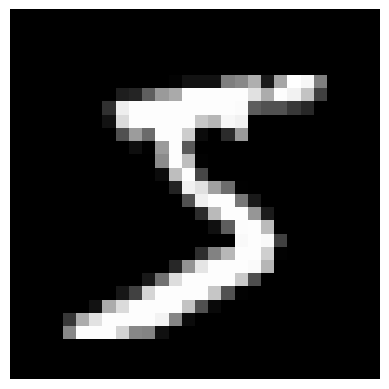

In [9]:
plt.imshow(train_images[0], cmap = 'gray'), plt.axis('off')
plt.show()

In [10]:
train_labels[0]

5

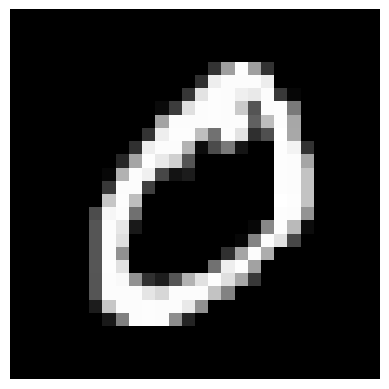

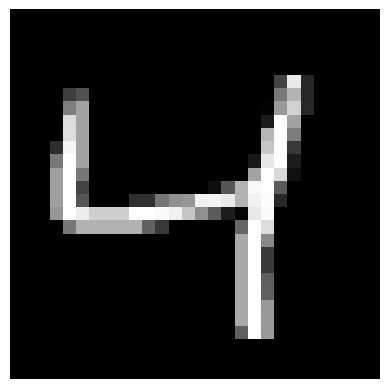

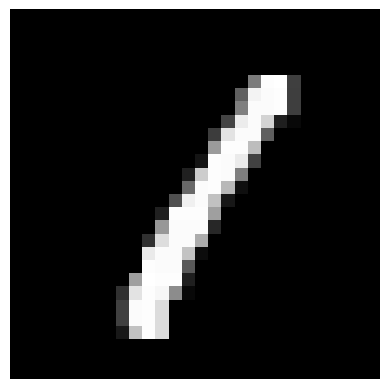

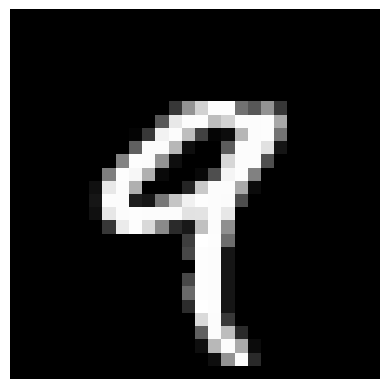

In [11]:
plt.imshow(train_images[1], cmap = 'gray'), plt.axis('off')
plt.show()

plt.imshow(train_images[2], cmap = 'gray'), plt.axis('off')
plt.show()

plt.imshow(train_images[3], cmap = 'gray'), plt.axis('off')
plt.show()

plt.imshow(train_images[4], cmap = 'gray'), plt.axis('off')
plt.show()

In [12]:
print(train_labels[1])
print(train_labels[2])
print(train_labels[3])
print(train_labels[4])

0
4
1
9


In [13]:
# Looks like the numbers match the images.  

In [14]:
# 3.  Build and train a Keras CNN classifier on the MNIST training set.

In [15]:
import numpy as np
from keras import models
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from keras.utils import to_categorical
import np_utils
from keras import backend as K

In [16]:
K.set_image_data_format("channels_first")
channels = 1
height = 28
width = 28

In [17]:
train_images = train_images.reshape(train_images.shape[0], channels, height, width)
test_images = test_images.reshape(test_images.shape[0], channels, height, width)

features_train = train_images/255
features_test = test_images/255

In [18]:
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)
number_of_classes = test_labels.shape[1]

In [19]:
network = Sequential()
network.add(Conv2D(filters = 64,
                   kernel_size = (5,5),
                   input_shape = (channels, width, height),
                   activation = 'relu'))

network.add(MaxPooling2D(pool_size = (2,2)))

network.add(Dropout(0.5))

network.add(Flatten())

network.add(Dense(128, activation = 'relu'))

network.add(Dropout(0.5))

network.add(Dense(number_of_classes, activation = 'softmax'))

C:\Users\jabbe\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
network.compile(loss = 'categorical_crossentropy',
                optimizer = 'rmsprop',
                metrics = ['accuracy'])

In [21]:
network.fit(features_train,
            train_labels,
            epochs = 2,
            verbose = 0,
            batch_size = 1000,
            validation_data = (features_test, test_labels))

In [22]:
# 4.  Report the test accuracy of your model.

In [23]:
test_loss, test_acc = network.evaluate(features_test, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - accuracy: 0.9618 - loss: 0.1283


In [24]:
test_acc

0.9678999781608582

In [25]:
# 5.  Display a confusion matrix on the test set classifications.

In [34]:
y_predicted = network.predict(features_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 220ms/step


In [46]:
y_predicted = np.argmax(y_predicted, axis=1)

In [48]:
y_predicted

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [50]:
test_labels_maxed = np.argmax(test_labels, axis=1)

In [51]:
test_labels_maxed

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

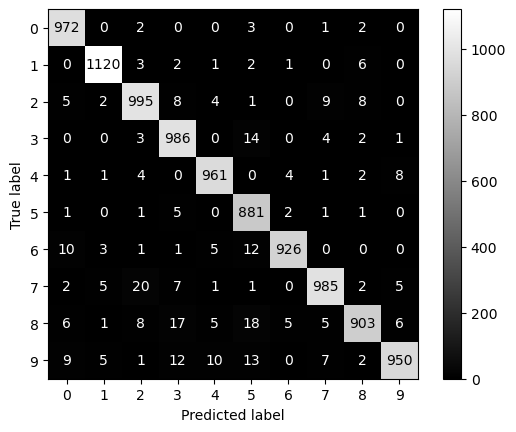

In [60]:
cm = confusion_matrix(test_labels_maxed, y_predicted)
cm_display = ConfusionMatrixDisplay(cm).plot(cmap='gray')

In [61]:
# 6.  Summarize your results.

In [63]:
# The model did a very good job of learning to identify the numbers, it identified 96.79% of the numbers in the 
# test data correctly after being trained.  Simpler models I saw online seem to only identify about 80-90% 
# correctly so the convolutional layer and the dropout layers do help strengthen the model's ability to identify
# the test data correctly.  

# I wonder if there's a way to strengthen the models ability to differentiate certain numbers from each other, or
# to check if it has a bias towards identifying an image as a certain number.  One thing I noticed from the 
# confusion matrix is that there are certain numbers it predicts the label to be incorrectly more often (5, 
# specifically, and 3 to a lesser extent).  Although the model is relatively robust already, a 3% error rate that
# could be reduced would be useful.